In [22]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from preprocessing.preprocessing_utils import nn_preprocess
from sklearn.metrics import mean_poisson_deviance

# Set random seed for reproducibility (Crucial for a "Reference" implementation)
torch.manual_seed(7)
np.random.seed(7)

print("Libraries loaded. PyTorch version:", torch.__version__)

Libraries loaded. PyTorch version: 2.6.0


In [23]:
# ==========================================
# 2. DATA LOADING & SPLITTING
# ==========================================
# Load raw data
train_full = pd.read_csv("../data/claims_train.csv")
test_raw = pd.read_csv("../data/claims_test.csv")

# CRITICAL STEP: Create a Validation set. 
# We tune on Val, and only touch Test once at the end.
train_subset, val_subset = train_test_split(train_full, test_size=0.2, random_state=42)

print(f"Full Train: {len(train_full)} | Train Subset: {len(train_subset)} | Val Subset: {len(val_subset)}")

# 1. Preprocess Train Subset (Fits the scaler)
X_train_df, y_train_s, w_train_s, scaler = nn_preprocess(train_subset, scaler=None)
train_cols = X_train_df.columns.tolist()

# 2. Preprocess Val Subset (Using Train scaler)
X_val_df, y_val_s, w_val_s, _ = nn_preprocess(val_subset, scaler=scaler, ref_columns=train_cols)

# 3. Preprocess Test Set (Using Train scaler)
X_test_df, y_test_s, w_test_s, _ = nn_preprocess(test_raw, scaler=scaler, ref_columns=train_cols)

# Helper to convert to Tensors
def to_tensor(df, y, w):
    X_t = torch.tensor(df.values.astype(np.float32))
    y_t = torch.tensor(y.values.astype(np.float32)).reshape(-1, 1)
    w_t = torch.tensor(w.values.astype(np.float32)).reshape(-1, 1)
    return X_t, y_t, w_t

X_train, y_train, w_train = to_tensor(X_train_df, y_train_s, w_train_s)
X_val, y_val, w_val = to_tensor(X_val_df, y_val_s, w_val_s)
X_test, y_test, w_test = to_tensor(X_test_df, y_test_s, w_test_s)

print(f"Feature Count: {X_train.shape[1]}")

Full Train: 542410 | Train Subset: 433928 | Val Subset: 108482
Feature Count: 124


In [24]:
# ==========================================
# 3. IMPROVED MODEL ARCHITECTURE
# ==========================================
class DynamicNN(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout_rate=0.2):
        super(DynamicNN, self).__init__()
        self.layers = nn.ModuleList()
        current_dim = input_dim
        
        for hidden_dim in hidden_layers:
            self.layers.append(nn.Linear(current_dim, hidden_dim))
            # Batch Norm stabilizes training
            #self.layers.append(nn.BatchNorm1d(hidden_dim))
            self.layers.append(nn.ReLU())
            # Dropout prevents overfitting
            self.layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim
            
        self.output_layer = nn.Linear(current_dim, 1)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        # Exponential activation for Poisson Rate (ensures positive output)
        return torch.exp(self.output_layer(x))

# def poisson_deviance_loss(y_pred, y_true, weight): used before
#     epsilon = 1e-8
#     y_pred = torch.clamp(y_pred, min=epsilon)
    
#     term1 = torch.zeros_like(y_true)
#     mask = y_true > 0
#     term1[mask] = y_true[mask] * torch.log(y_true[mask] / y_pred[mask])
    
#     term2 = y_true - y_pred
#     deviance = 2 * weight * (term1 - term2)
#     return torch.mean(deviance)

def mean_weighted_poisson_deviance_loss(y_pred, y_true, w):
    eps = 1e-10
    y_pred = torch.clamp(y_pred, min=eps)

    term1 = torch.zeros_like(y_true)
    mask = y_true > 0
    term1[mask] = y_true[mask] * torch.log(y_true[mask] / y_pred[mask])

    dev_i = 2.0 * (term1 - (y_true - y_pred))          # per-sample deviance
    
    return torch.sum(w * dev_i) / (torch.sum(w) + eps) # weighted mean (sklearn-style)




In [25]:
# ==========================================
# 4. TRAINING LOOP WITH EARLY STOPPING
# ==========================================
def run_experiment(config, lr, weight_decay, epochs=500, batch_size=1024, verbose=False):
    """
    Trains on Train Subset, Evaluates on Validation Subset.
    Implements Early Stopping with weights restoration.
    """
    input_dim = X_train.shape[1]
    model = DynamicNN(input_dim, config, dropout_rate=0.2)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    n_samples = X_train.size(0)
    
    # Early Stopping variables
    best_val_loss = float('inf')
    best_model_state = None 
    patience = 15     # How many epochs to wait
    counter = 0
    
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n_samples)
        
        for i in range(0, n_samples, batch_size):
            indices = permutation[i:i+batch_size]
            batch_x = X_train[indices]
            batch_y = y_train[indices]
            batch_w = w_train[indices]

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = mean_weighted_poisson_deviance_loss(outputs, batch_y, batch_w)
            loss.backward()
            optimizer.step()
            
        
        # --- Validation Check ---
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = mean_weighted_poisson_deviance_loss(val_pred, y_val, w_val).item()
            
        if verbose and (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | Val Loss: {val_loss:.5f}")
            
        # --- Early Stopping Logic ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict()) # Save best weights
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                if verbose: print(f"Early stopping triggered at epoch {epoch+1}")
                break
    
    # Restore best model before returning
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
                
    return best_val_loss

In [26]:
# ==========================================
# 5. HYPERPARAMETER TUNING
# ==========================================
architectures = [
    [32], [64], [128],
    [64, 32], [128, 64],
    [64, 32, 16], [128, 64, 32]
]

# Grid Search Variables
fixed_lr = 0.001
fixed_reg = 0.01

print(f"{'Architecture':<20} | {'Val Deviance':<15}")
print("-" * 40)

arch_results = {}

for arch in architectures:
    # Note: We now minimize VALIDATION Deviance
    deviance = run_experiment(config=arch, lr=fixed_lr, weight_decay=fixed_reg, 
                              epochs=100, batch_size=1024, verbose=False)
    arch_results[str(arch)] = deviance
    print(f"{str(arch):<20} | {deviance:.5f}")

best_arch_str = min(arch_results, key=arch_results.get)
best_arch = eval(best_arch_str)
print("-" * 40)
print(f"Winner Architecture: {best_arch}")

# --- Tune Learning Rate & Regularization ---
learning_rates = [0.005, 0.001, 0.0005] 
regularizations = [0.0, 0.001, 0.01]

print(f"\nTuning for Architecture: {best_arch}")
print(f"{'LR':<8} | {'Reg':<8} | {'Val Deviance':<15}")
print("-" * 40)

best_loss = float('inf')
best_params = {}

for lr in learning_rates:
    for reg in regularizations:
        deviance = run_experiment(config=best_arch, lr=lr, weight_decay=reg, 
                                  epochs=100, batch_size=1024, verbose=False)
        
        print(f"{lr:<8} | {reg:<8} | {deviance:.5f}")
        
        if deviance < best_loss:
            best_loss = deviance
            best_params = {'lr': lr, 'reg': reg}

print("-" * 40)
print(f"Best Params: {best_params} with Val Deviance: {best_loss:.5f}")

Architecture         | Val Deviance   
----------------------------------------
[32]                 | 0.59041
[64]                 | 0.59001
[128]                | 0.59067
[64, 32]             | 0.58855
[128, 64]            | 0.58948
[64, 32, 16]         | 0.58843
[128, 64, 32]        | 0.58849
----------------------------------------
Winner Architecture: [64, 32, 16]

Tuning for Architecture: [64, 32, 16]
LR       | Reg      | Val Deviance   
----------------------------------------
0.005    | 0.0      | 0.59010
0.005    | 0.001    | 0.59002
0.005    | 0.01     | 0.59080
0.001    | 0.0      | 0.58896
0.001    | 0.001    | 0.59007
0.001    | 0.01     | 0.58887
0.0005   | 0.0      | 0.58956
0.0005   | 0.001    | 0.58937
0.0005   | 0.01     | 0.58913
----------------------------------------
Best Params: {'lr': 0.001, 'reg': 0.01} with Val Deviance: 0.58887



Training Final Model ([64, 32, 16]) with Early Stopping...


Epoch 10: Val Loss 0.59114
Epoch 20: Val Loss 0.59015
Epoch 30: Val Loss 0.59098
Epoch 40: Val Loss 0.59125
Early stopping triggered at epoch 42
Best model weights restored.

=== TRUE M2 PERFORMANCE (TEST SET) ===
Mean Poisson Deviance: 0.58881
D^2 Score: 6.99%


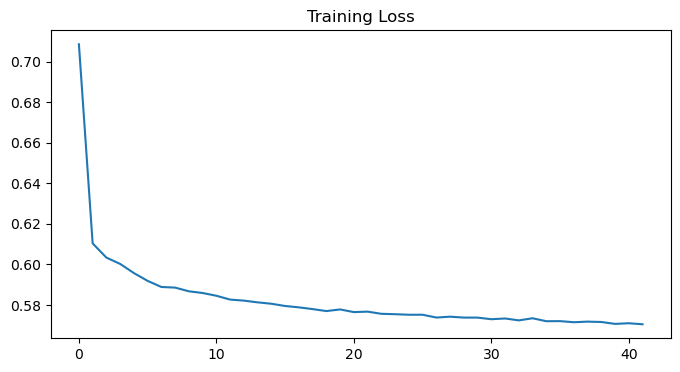

/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_16185/3099503789.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(cum_claims.flatten(), cum_exposure.flatten())


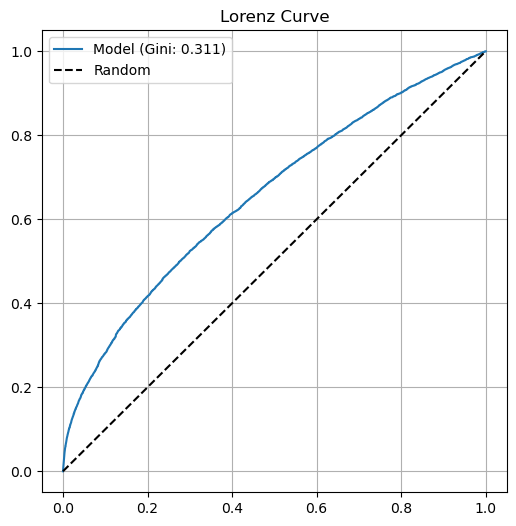

/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_16185/3099503789.py:174: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby('Bin').apply(lambda x: pd.Series({
/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_16185/3099503789.py:174: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = df.groupby('Bin').apply(lambda x: pd.Series({


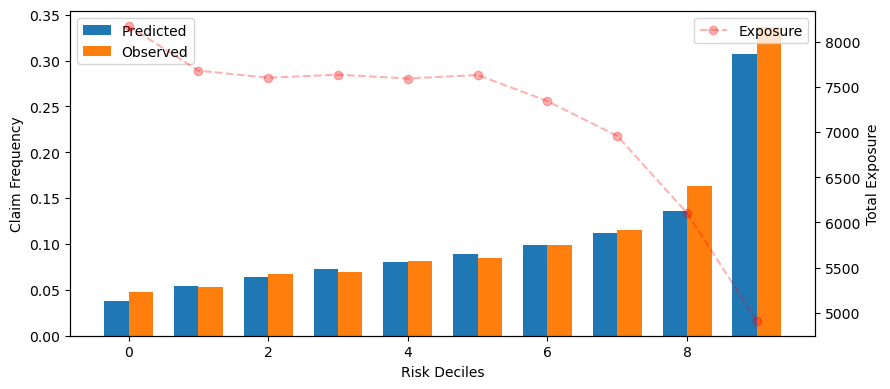

In [27]:
# ==========================================
# 6. FINAL TRAINING & PLOTTING
# ==========================================
final_lr = best_params['lr']
final_reg = best_params['reg']

print(f"\nTraining Final Model ({best_arch}) with Early Stopping...")

# 1. Initialize fresh model
model = DynamicNN(X_train.shape[1], best_arch, dropout_rate=0.2)
optimizer = optim.AdamW(model.parameters(), lr=final_lr, weight_decay=final_reg)

# 2. Train with Early Stopping (Re-using the logic from tuning)
# Note: We do NOT merge X_train and X_val here. We use X_val to stop at the right time.
best_val_loss = float('inf')
best_model_state = None
patience = 15
counter = 0
final_epochs = 500  # Set high, let Early Stopping handle it
loss_history = []

for epoch in range(final_epochs):
    model.train()
    permutation = torch.randperm(X_train.size(0))
    epoch_num = 0.0
    epoch_den = 0.0
    
    for i in range(0, X_train.size(0), 1024):   
        indices = permutation[i:i+1024]
        batch_x = X_train[indices]
        batch_y = y_train[indices]
        batch_w = w_train[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = mean_weighted_poisson_deviance_loss(outputs, batch_y, batch_w)
        loss.backward()
        optimizer.step()
        
        # accumulate weighted numerator/denominator so epoch average matches project deviance
        batch_pred = outputs.detach()
        batch_true = batch_y
        batch_w    = batch_w

        eps = 1e-10
        batch_pred = torch.clamp(batch_pred, min=eps)

        term1 = torch.zeros_like(batch_true)
        mask = batch_true > 0
        term1[mask] = batch_true[mask] * torch.log(batch_true[mask] / batch_pred[mask])

        dev_i = 2.0 * (term1 - (batch_true - batch_pred))  # per-sample deviance
        epoch_num += torch.sum(batch_w * dev_i).item()
        epoch_den += torch.sum(batch_w).item()
        

    avg_loss = epoch_num / (epoch_den + 1e-12)
    loss_history.append(avg_loss)

    
    # --- Validation Check ---
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = mean_weighted_poisson_deviance_loss(val_pred, y_val, w_val).item()
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict()) # Save best weights
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Val Loss {val_loss:.5f}")

# 3. Load the best weights found
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Best model weights restored.")

# --- Generate Plots & Metrics ---
# def sklearn_poisson_deviance(y_true, y_pred, weight): we use built in function instead
#     if isinstance(y_true, torch.Tensor): y_true = y_true.numpy()
#     if isinstance(y_pred, torch.Tensor): y_pred = y_pred.detach().numpy()
#     if isinstance(weight, torch.Tensor): weight = weight.numpy()
#     y_pred = np.clip(y_pred, 1e-10, None)
#     term1 = np.zeros_like(y_true)
#     mask = y_true > 0
#     term1[mask] = y_true[mask] * np.log(y_true[mask] / y_pred[mask])
#     term2 = -(y_true - y_pred)
#     return np.sum(2 * weight * (term1 + term2)) / np.sum(weight)




# model.eval()
# with torch.no_grad():
#     y_pred_test = model(X_test).numpy()
#     y_true_test = y_test.numpy()
#     w_test_numpy = w_test.numpy()

# final_m2_deviance = mean_poisson_deviance(y_true_test, y_pred_test, w_test_numpy)

# # D^2 Calculation
# global_mean_freq = np.average(y_true_test, weights=w_test_numpy)
# y_null = np.full_like(y_true_test, global_mean_freq)
# null_deviance = mean_poisson_deviance(y_true_test, y_null, w_test_numpy)
# d2_score = 1 - (final_m2_deviance / null_deviance)

# print(f"\n=== TRUE M2 PERFORMANCE (TEST SET) ===")
# print(f"Mean Poisson Deviance: {final_m2_deviance:.5f}")
# print(f"D^2 Score: {d2_score:.2%}")


model.eval()
with torch.no_grad():
    y_pred_test = model(X_test).detach().cpu().numpy().ravel()

y_true_test  = y_test.detach().cpu().numpy().ravel()
w_test_numpy = w_test.detach().cpu().numpy().ravel()

# Project metric (exactly like your other models)
final_m2_deviance = mean_poisson_deviance(y_true_test, y_pred_test, sample_weight=w_test_numpy)

# D^2 Calculation (null model predicts weighted mean frequency)
global_mean_freq = np.average(y_true_test, weights=w_test_numpy)
y_null = np.full_like(y_true_test, global_mean_freq)

null_deviance = mean_poisson_deviance(y_true_test, y_null, sample_weight=w_test_numpy)
d2_score = 1 - (final_m2_deviance / null_deviance)

print(f"\n=== TRUE M2 PERFORMANCE (TEST SET) ===")
print(f"Mean Poisson Deviance: {final_m2_deviance:.5f}")
print(f"D^2 Score: {d2_score:.2%}")


# --- PLOTTING FUNCTIONS ---
def plot_lorenz_curve(y_true, y_pred, exposure):
    order = np.argsort(y_pred, axis=0)[::-1].flatten()
    y_true_sorted = y_true[order]
    exposure_sorted = exposure[order]
    
    cum_exposure = np.cumsum(exposure_sorted)
    cum_exposure /= cum_exposure[-1] 
    
    cum_claims = np.cumsum(y_true_sorted * exposure_sorted)
    cum_claims /= cum_claims[-1]
    
    auc = np.trapz(cum_claims.flatten(), cum_exposure.flatten())
    gini = (auc - 0.5) / 0.5
    
    plt.figure(figsize=(6, 6))
    plt.plot(cum_exposure, cum_claims, label=f'Model (Gini: {gini:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.title("Lorenz Curve")
    plt.legend()
    plt.grid(True)
    plt.show()
    return gini

def plot_calibration(y_true, y_pred, exposure, n_bins=10):
    df = pd.DataFrame({
        'Obs': y_true.flatten(),
        'Pred': y_pred.flatten(),
        'Exp': exposure.flatten()
    })

    df['Bin'] = pd.qcut(df['Pred'], n_bins, duplicates='drop')

    g = df.groupby('Bin').apply(lambda x: pd.Series({
        'Pred': np.average(x['Pred'], weights=x['Exp']),
        'Obs':  np.average(x['Obs'],  weights=x['Exp']),
        'Exp':  x['Exp'].sum()
    }))

    x = np.arange(len(g))
    w = 0.35

    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.bar(x - w/2, g['Pred'], w, label='Predicted')
    ax1.bar(x + w/2, g['Obs'],  w, label='Observed')
    ax1.set_ylabel('Claim Frequency')
    ax1.set_xlabel('Risk Deciles')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(x, g['Exp'], 'r--o', alpha=0.3, label='Exposure')
    ax2.set_ylabel('Total Exposure')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


# Run Plots
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.show()

gini_score = plot_lorenz_curve(y_true_test, y_pred_test, w_test_numpy)
plot_calibration(y_true_test, y_pred_test, w_test_numpy)

In [28]:
from sklearn.metrics import mean_poisson_deviance

model.eval()
with torch.no_grad():
    # Predictions
    y_pred_val  = model(X_val).detach().cpu().numpy().ravel()
    y_pred_test = model(X_test).detach().cpu().numpy().ravel()

# True + weights
y_true_val = y_val.detach().cpu().numpy().ravel()
w_val_np   = w_val.detach().cpu().numpy().ravel()

y_true_test = y_test.detach().cpu().numpy().ravel()
w_test_np   = w_test.detach().cpu().numpy().ravel()

# Deviances (project metric)
val_dev  = mean_poisson_deviance(y_true_val,  y_pred_val,  sample_weight=w_val_np)
test_dev = mean_poisson_deviance(y_true_test, y_pred_test, sample_weight=w_test_np)

print("\n=== PERFORMANCE (PROJECT METRIC) ===")
print(f"Val  Mean Poisson Deviance: {val_dev:.5f}")
print(f"Test Mean Poisson Deviance: {test_dev:.5f}")



=== PERFORMANCE (PROJECT METRIC) ===
Val  Mean Poisson Deviance: 0.58972
Test Mean Poisson Deviance: 0.58881
